# Calculation of occupational-level green/brown shares based on ESCO and ONET data
Felix Zaussinger | 17.05.2022

**Core Analysis Goal(s)**
1. Calculate g/b shares based on ESCO skills data
2. Collect g/b shares based on various ONET data at different granularity levels
3. Combine into a central data set
4. Derive a final data set by using both ESCO and ONET data to triangulate green and brown occupations

**Overview of data sets**

1 ONET: Vona 2018 (Greenness), SOC 8-digit matched via ONET-ESCO crosswalk [CHECK]
2 ONET: GTP 2011 (Greenness), SOC 8-digit matched via ONET-ESCO crosswalk [CHECK]
3 ONET: Vona 2019 (Greenness), SOC 6-digit matched via IBS SOC-ISCO crosswalk
4 ONET: JRC/Consoli (Greenness), CP-2011 5-digit matched via CP2011-ESCO crosswalk
5 ESCO: ESCO 2022 (Greenness) [CHECK]

**Key Insight(s)**
1.
2.
 3.

## Setup

In [3]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

**Results settings**

In [4]:
# specify whether nan values of green/brown shares matched to ESCO should be filled

# NOTE (!!!): not filling nans currently yields wrong correlation matrices because
#  all nans are dropped simultaneously, not pairwise
fill_nans_after_merging = True

# define branches of results folder based on nan fill policy
out_folder_branch = None
if fill_nans_after_merging:
    out_folder_branch = "nan_values_filled"
else:
    out_folder_branch = "nan_values_kept"

# p-value for correlation matrix plots
pval = 0.01

**Initialise main objects**

In [5]:
from src.data.framework import Esco, Onet, Classifications, Crosswalks

esco = Esco()
onet = Onet()
classifications = Classifications()
crosswalks = Crosswalks()

## Data reading and merging

### 1) Combine ESCO skills metadata

In [6]:
var_sel_skills = [
    'conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel',
    'skill_green_esco', 'skill_brown_esco', 'skill_neutral_esco', 'skill_classification_esco',
    'skill_green_eth', 'skill_brown_eth', 'machineScore_green', 'machineScore_brown',
]

smd = esco.combine_skills_metadata(override=True, variable_selection=var_sel_skills)
smd.head()

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,skill_green_esco,skill_brown_esco,skill_neutral_esco,skill_classification_esco,skill_green_eth,skill_brown_eth,machineScore_green,machineScore_brown
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,False,False,True,neutral,NaN,NaN,NaN,NaN
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,False,False,True,neutral,NaN,NaN,NaN,NaN
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,False,False,True,neutral,NaN,NaN,NaN,NaN
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,False,False,True,neutral,NaN,NaN,NaN,NaN
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,False,False,True,neutral,NaN,NaN,NaN,NaN


### 2) Calculate GBN occupation shares based on ESCO skill classifications

In [7]:
# based on essential and optional skills, unweighted
esco_gbn_shares_all = esco.calc_gbn_shares_skill_based(skills_metadata=smd, drop_counts=True, essential_only=False)

# based on essential skills only (similar to core greenness in Vona et al. 2019)
esco_gbn_shares_ess = esco.calc_gbn_shares_skill_based(skills_metadata=smd, drop_counts=True, essential_only=True)

T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\framework.py:1435: RuntimeWarning: invalid value encountered in true_divide
  occ_share = n_gbn_specific_skills / n_total_specific_skills


In [8]:
esco_gbn_shares_ess.columns

Index(['conceptUri', 'share_green_esco', 'share_brown_esco',
       'share_neutral_esco', 'gbn_classification_esco'],
      dtype='object')

### **3) Combine ESCO-level occupation metadata**

In [9]:
var_sel_occs = [
    "conceptUri", "preferredLabel", "description", "isco_level_4", "isco_level_3", "isco_level_2", "isco_level_1", "isco_label_4", "isco_label_3", "isco_label_2", "isco_label_1",
    'share_green_esco', 'share_brown_esco', 'share_neutral_esco', 'gbn_classification_esco',
    'share_green_esco_ess', 'share_brown_esco_ess', 'share_neutral_esco_ess', 'gbn_classification_esco_ess',
]

omd = esco.combine_occupation_metadata(skills_metadata=smd, variable_selection=var_sel_occs)

T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\framework.py:1435: RuntimeWarning: invalid value encountered in true_divide
  occ_share = n_gbn_specific_skills / n_total_specific_skills


#### **4) Join 8-digit ONET-level occupation metadata to Nesta crosswalk**

In [10]:
# read Nesta crosswalk
cw_onet_esco = crosswalks.onet_esco_mcc_full
cw_onet_esco

,id,concept_uri,preferred_label,isco_level_4,onet_code,onet_occupation,onet_code_6d
0,0,http://data.europa.eu/esco/occupation/00030d09...,technical director,2166,27-1011.00,art directors,27-1011
1,1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,8121,51-4021.00,"extruding and drawing machine setters, operato...",51-4021
2,2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,7543,51-9061.00,"inspectors, testers, sorters, samplers, and we...",51-9061
3,3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,3155,17-3023.01,electronics engineering technicians,17-3023
4,4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,2431,13-1161.00,market research analysts and marketing special...,13-1161
...,...,...,...,...,...,...,...
2937,2937,http://data.europa.eu/esco/occupation/ff656b3a...,demographer,2120,15-2041.00,statisticians,15-2041
2938,2938,http://data.europa.eu/esco/occupation/ff8d4065...,sorter labourer,9612,51-9199.01,recycling and reclamation workers,51-9199
2939,2939,http://data.europa.eu/esco/occupation/ffa4dd5d...,armoured car guard,5414,33-9032.00,security guards,33-9032
2940,2940,http://data.europa.eu/esco/occupation/ffade2f4...,civil service administrative officer,2422,11-3011.00,administrative services managers,11-3011


Join Vona 2018 data to crosswalk at ONET 8-digit level

In [11]:
cw_onet_esco_merged = pd.merge(
    cw_onet_esco,
    onet.green_occupations_vona2018[["onet_code", "share_green_vona2018"]],
    on="onet_code",
    how="left"
)

# clean
cw_onet_esco_merged

,id,concept_uri,preferred_label,isco_level_4,onet_code,onet_occupation,onet_code_6d,share_green_vona2018
0,0,http://data.europa.eu/esco/occupation/00030d09...,technical director,2166,27-1011.00,art directors,27-1011,NaN
1,1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,8121,51-4021.00,"extruding and drawing machine setters, operato...",51-4021,NaN
2,2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,7543,51-9061.00,"inspectors, testers, sorters, samplers, and we...",51-9061,0.0625
3,3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,3155,17-3023.01,electronics engineering technicians,17-3023,NaN
4,4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,2431,13-1161.00,market research analysts and marketing special...,13-1161,NaN
...,...,...,...,...,...,...,...,...
2937,2937,http://data.europa.eu/esco/occupation/ff656b3a...,demographer,2120,15-2041.00,statisticians,15-2041,NaN
2938,2938,http://data.europa.eu/esco/occupation/ff8d4065...,sorter labourer,9612,51-9199.01,recycling and reclamation workers,51-9199,1.0000
2939,2939,http://data.europa.eu/esco/occupation/ffa4dd5d...,armoured car guard,5414,33-9032.00,security guards,33-9032,NaN
2940,2940,http://data.europa.eu/esco/occupation/ffade2f4...,civil service administrative officer,2422,11-3011.00,administrative services managers,11-3011,NaN


Join GTP 2011 data to crosswalk at ONET 8-digit level

In [12]:
cw_onet_esco_merged = pd.merge(
    cw_onet_esco_merged,
    onet.green_occupations_gtp[["onet_code", "share_green_gtp"]],
    on="onet_code",
    how="left"
)

cw_onet_esco_merged

,id,concept_uri,preferred_label,isco_level_4,onet_code,onet_occupation,onet_code_6d,share_green_vona2018,share_green_gtp
0,0,http://data.europa.eu/esco/occupation/00030d09...,technical director,2166,27-1011.00,art directors,27-1011,NaN,NaN
1,1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,8121,51-4021.00,"extruding and drawing machine setters, operato...",51-4021,NaN,NaN
2,2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,7543,51-9061.00,"inspectors, testers, sorters, samplers, and we...",51-9061,0.0625,0.0625
3,3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,3155,17-3023.01,electronics engineering technicians,17-3023,NaN,NaN
4,4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,2431,13-1161.00,market research analysts and marketing special...,13-1161,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2937,2937,http://data.europa.eu/esco/occupation/ff656b3a...,demographer,2120,15-2041.00,statisticians,15-2041,NaN,NaN
2938,2938,http://data.europa.eu/esco/occupation/ff8d4065...,sorter labourer,9612,51-9199.01,recycling and reclamation workers,51-9199,1.0000,1.0000
2939,2939,http://data.europa.eu/esco/occupation/ffa4dd5d...,armoured car guard,5414,33-9032.00,security guards,33-9032,NaN,NaN
2940,2940,http://data.europa.eu/esco/occupation/ffade2f4...,civil service administrative officer,2422,11-3011.00,administrative services managers,11-3011,NaN,NaN


#### 5) Join 6-digit ONET-level occupation metadata to offical SOC 6D - ISCO 4D crosswalk

Read official BLS SOC 2010 6D - ISCO-08 4D crosswalk

In [13]:
cw_soc_isco = crosswalks.soc10_isco08_bls(direction="soc_to_isco")
cw_soc_isco

,soc10_code,soc10_title,isco08_code,isco08_title
0,11-1011,Chief Executives,1112,Senior government officials
1,11-1011,Chief Executives,1113,Traditional chiefs and heads of villages
2,11-1011,Chief Executives,1120,Managing directors and chief executives
3,11-1021,General and Operations Managers,1112,Senior government officials
4,11-1021,General and Operations Managers,1114,Senior officials of special-interest organizat...
...,...,...,...,...
1120,55-3015,Command and Control Center Specialists,0310,"Armed forces occupations, other ranks"
1121,55-3016,Infantry,0310,"Armed forces occupations, other ranks"
1122,55-3017,Radar and Sonar Technicians,0310,"Armed forces occupations, other ranks"
1123,55-3018,Special Forces,0310,"Armed forces occupations, other ranks"


Join 6-digit level brown classification from Vona et al. 2018

In [14]:
brown_occupations_vona2018 = onet.brown_occupations_vona2018
#brown_occupations_vona2018["soc_code"] = brown_occupations_vona2018["soc_code"].str
# .replace("-", "").astype(int)
brown_occupations_vona2018["is_brown_vona2018"] = np.ones(
    brown_occupations_vona2018.shape[0], dtype=int
)

In [15]:
cw_soc_isco_merged = pd.merge(
    cw_soc_isco,
    brown_occupations_vona2018.drop(columns=["occupation"]),
    left_on="soc10_code",
    right_on="soc_code",
    how="left"
).drop(columns=["soc_code"])

# optional: fill nan values of shares with zeros
if fill_nans_after_merging:
    cw_soc_isco_merged["is_brown_vona2018"] = cw_soc_isco_merged["is_brown_vona2018"].fillna(0)
cw_soc_isco_merged["soc10_n_occs"] = 1

In [16]:
cw_soc_isco_merged

,soc10_code,soc10_title,isco08_code,isco08_title,is_brown_vona2018,soc10_n_occs
0,11-1011,Chief Executives,1112,Senior government officials,0.0,1
1,11-1011,Chief Executives,1113,Traditional chiefs and heads of villages,0.0,1
2,11-1011,Chief Executives,1120,Managing directors and chief executives,0.0,1
3,11-1021,General and Operations Managers,1112,Senior government officials,0.0,1
4,11-1021,General and Operations Managers,1114,Senior officials of special-interest organizat...,0.0,1
...,...,...,...,...,...,...
1122,55-3015,Command and Control Center Specialists,0310,"Armed forces occupations, other ranks",0.0,1
1123,55-3016,Infantry,0310,"Armed forces occupations, other ranks",0.0,1
1124,55-3017,Radar and Sonar Technicians,0310,"Armed forces occupations, other ranks",0.0,1
1125,55-3018,Special Forces,0310,"Armed forces occupations, other ranks",0.0,1


Join 6-digit level greeness scores from Vona et al. 2019

In [17]:
green_occupations_vona2019 = onet.green_occupations_vona2019(agg_to_6d_soc=True)

cw_soc_isco_merged = pd.merge(
    cw_soc_isco_merged,
    green_occupations_vona2019,
    left_on="soc10_code",
    right_on="soc10_6d_code",
    how="left"
).drop(columns=["soc10_6d_code"])

# optional: fill nan values of shares with zeros
if fill_nans_after_merging:
    cw_soc_isco_merged["share_green_vona2019"] = cw_soc_isco_merged["share_green_vona2019"].fillna(0)

cw_soc_isco_merged

,soc10_code,soc10_title,isco08_code,isco08_title,is_brown_vona2018,soc10_n_occs,share_green_vona2019
0,11-1011,Chief Executives,1112,Senior government officials,0.0,1,0.0
1,11-1011,Chief Executives,1113,Traditional chiefs and heads of villages,0.0,1,0.0
2,11-1011,Chief Executives,1120,Managing directors and chief executives,0.0,1,0.0
3,11-1021,General and Operations Managers,1112,Senior government officials,0.0,1,0.0
4,11-1021,General and Operations Managers,1114,Senior officials of special-interest organizat...,0.0,1,0.0
...,...,...,...,...,...,...,...
1122,55-3015,Command and Control Center Specialists,0310,"Armed forces occupations, other ranks",0.0,1,0.0
1123,55-3016,Infantry,0310,"Armed forces occupations, other ranks",0.0,1,0.0
1124,55-3017,Radar and Sonar Technicians,0310,"Armed forces occupations, other ranks",0.0,1,0.0
1125,55-3018,Special Forces,0310,"Armed forces occupations, other ranks",0.0,1,0.0


#### **Aggregate 6D SOC data at ISCO 4D level**

In [18]:
grouping_col = "isco08_code"

agg_dict = {
    "is_brown_vona2018": np.nanmean,
    "share_green_vona2019": np.nanmean,
    "soc10_n_occs": np.nansum,
    "isco08_title": "first"
}

onet_to_isco_4d = cw_soc_isco_merged.groupby(grouping_col).aggregate(agg_dict)
onet_to_isco_4d = onet_to_isco_4d.reset_index()
onet_to_isco_4d = onet_to_isco_4d.rename(columns={"is_brown_vona2018": "share_brown_vona2018"})
onet_to_isco_4d.to_csv(os.path.join(useful_paths.data_interim, "onet",
                                    "occupation_shares_soc6d_to_isco4d_vona2018_2019"
                                    ".csv"))
onet_to_isco_4d

,isco08_code,share_brown_vona2018,share_green_vona2019,soc10_n_occs,isco08_title
0,0110,0.0,0.0,8,Commissioned armed forces officers
1,0210,0.0,0.0,3,Non-commissioned armed forces officers
2,0310,0.0,0.0,9,"Armed forces occupations, other ranks"
3,1111,0.0,0.0,1,Legislators
4,1112,0.0,0.0,3,Senior government officials
...,...,...,...,...,...
436,9621,0.0,0.0,2,"Messengers, package deliverers and luggage por..."
437,9622,0.0,0.0,4,Odd job persons
438,9623,0.5,0.0,2,Meter readers and vending-machine collectors
439,9624,0.0,0.0,1,Water and firewood collectors


**Problematic due to high green & brown shares:**
7119; Building frame and related trades workers not elsewhere classified
8114; Cement, stone and other mineral products machine operators
3132; Incinerator and water treatment plant operators

In [19]:
onet_to_isco_4d.sort_values("share_green_vona2019", ascending=False).head(5)

,isco08_code,share_brown_vona2018,share_green_vona2019,soc10_n_occs,isco08_title
45,2143,0.0,1.00000,1,Environmental engineers
33,1439,0.0,0.40535,1,Services managers not elsewhere classified
10,1213,0.0,0.40535,1,Policy and planning managers
28,1349,0.0,0.40535,1,Professional services managers not elsewhere c...
18,1322,0.0,0.40535,1,Mining managers


In [20]:
onet_to_isco_4d[(onet_to_isco_4d.share_brown_vona2018 > 0) & (onet_to_isco_4d
                                                              .share_green_vona2019 >
                                                              0)]

,isco08_code,share_brown_vona2018,share_green_vona2019,soc10_n_occs,isco08_title
127,3111,0.333333,0.1199,3,Chemical and physical science technicians
140,3132,0.250000,0.2500,4,Incinerator and water treatment plant operators
371,8114,0.250000,0.2500,4,"Cement, stone and other mineral products machi..."


**NOTE: Manual assignment for 8114, 3132**
as an option, but keep transparency now!

In [21]:
#onet_to_isco_4d.loc[onet_to_isco_4d.isco08_code == "8114", "share_green_vona2019"] = 0
#onet_to_isco_4d.loc[onet_to_isco_4d.isco08_code == "3132", "share_brown_vona2018"] = 0

In [22]:
(onet_to_isco_4d.share_brown_vona2018 > 0).sum()

59

### **7) Combine all information into a single ESCO-level data set, attaching ONET data
either via ESCO directly (ONET 8-digits), or via ISCO (SOC 6-digits)**

In [23]:
occ_master_ds = omd.copy()

#### Join 8-digit ONET data (via Nesta crosswalk)

In [24]:
occ_master_ds = pd.merge(
    occ_master_ds,
    cw_onet_esco_merged[["concept_uri", "share_green_gtp", "share_green_vona2018"]],
    left_on="conceptUri",
    right_on="concept_uri",
    how="left"
).drop(columns="concept_uri")

# optional: fill nan values of shares with zeros
if fill_nans_after_merging:
    occ_master_ds["share_green_gtp"] = occ_master_ds["share_green_gtp"].fillna(0)
    occ_master_ds["share_green_vona2018"] = occ_master_ds["share_green_vona2018"].fillna(0)
occ_master_ds

,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_brown_esco,share_neutral_esco,gbn_classification_esco,share_green_esco_ess,share_brown_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,share_green_gtp,share_green_vona2018
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.052632,0.0,0.947368,neutral,0.055556,0.0,0.944444,neutral,0.0,0.0
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,9520,952,95,9,Street vendors (excluding food),Street vendors (excluding food),Street and related sales and service workers,Elementary occupations,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.040000,0.0,0.960000,neutral,0.058824,0.0,0.941176,neutral,0.0,0.0
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.047619,0.0,0.952381,neutral,0.066667,0.0,0.933333,neutral,0.0,0.0
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,9412,941,94,9,Kitchen helpers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.064516,0.0,0.935484,neutral,0.100000,0.0,0.900000,neutral,0.0,0.0


#### Compute CP-2011 5D greenness shares (JRC/Consoli)

In [25]:
greenness_shares_jrc = pd.merge(
    crosswalks.esco_it_cp2011,
    onet.green_occupations_narrow_jrc,
    left_on="Classification_2_ID",
    right_on="isco08_jrc",
    how="left",
    validate="m:1"
).rename(columns={"greenness_jrc": "share_green_jrc"})

# optional: fill nan values of shares with zeros
if fill_nans_after_merging:
    greenness_shares_jrc["share_green_jrc"] = \
        greenness_shares_jrc["share_green_jrc"].fillna(0)

# aggregate by ESCO URI
greenness_shares_jrc_agg = greenness_shares_jrc.groupby("Classification_1_URI")\
    .aggregate(
    {"share_green_jrc": np.nanmean}
).reset_index()

(greenness_shares_jrc_agg.share_green_jrc > 0).sum()

603

Problem: crosswalk includes 38 ISCO 4D/3D matches, 6 of which have a greenness scores

In [26]:
it_isco = greenness_shares_jrc_agg.Classification_1_URI.str.contains("isco")

In [27]:
(greenness_shares_jrc_agg[it_isco]).shape

(38, 2)

In [28]:
(greenness_shares_jrc_agg[it_isco].share_green_jrc > 0).sum()

6

Join CP-2011 5D greenness shares (JRC/Consoli) via ESCO URIs

In [29]:
occ_master_ds = pd.merge(
    occ_master_ds,
    greenness_shares_jrc_agg,
    left_on="conceptUri",
    right_on="Classification_1_URI",
    how="left"
).drop(columns=["Classification_1_URI"])

Join 6-digit ONET data (via ISCO 4D codes)

In [30]:
occ_master_ds = pd.merge(
    occ_master_ds,
    onet_to_isco_4d,
    left_on="isco_level_4",
    right_on="isco08_code",
    how="left"
).drop(columns=["isco08_code", "soc10_n_occs", "isco08_title"])

In [31]:
occ_master_ds

,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_brown_esco,share_neutral_esco,gbn_classification_esco,share_green_esco_ess,share_brown_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_vona2018,share_green_vona2019
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.052632,0.0,0.947368,neutral,0.055556,0.0,0.944444,neutral,0.0,0.0,0.000000,0.0,0.0
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,9520,952,95,9,Street vendors (excluding food),Street vendors (excluding food),Street and related sales and service workers,Elementary occupations,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.040000,0.0,0.960000,neutral,0.058824,0.0,0.941176,neutral,0.0,0.0,0.000000,0.0,0.0
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.047619,0.0,0.952381,neutral,0.066667,0.0,0.933333,neutral,0.0,0.0,0.000000,0.0,0.0
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,9412,941,94,9,Kitchen helpers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.064516,0.0,0.935484,neutral,0.100000,0.0,0.900000,neutral,0.0,0.0,0.083333,0.0,0.0


Join Gilli et al. 2020 greenness shares at ISCO 3D level

In [32]:
occ_master_ds = pd.merge(
    occ_master_ds,
    onet.green_occupations_gilli2020,
    left_on="isco_level_3",
    right_on="ISCO_code",
    how="left"
).drop(columns=["ISCO_code"])

#### **Save final occupation metadata set to data/interim**

In [33]:
utils.save_df_to_files(
    df=occ_master_ds,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

In [34]:
occ_master_ds

,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_brown_esco,share_neutral_esco,gbn_classification_esco,share_green_esco_ess,share_brown_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_vona2018,share_green_vona2019,share_green_gilli2020
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,Video and motion picture directors are respons...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,Performance lighting directors determine what ...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.052632,0.0,0.947368,neutral,0.055556,0.0,0.944444,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,Animation directors supervise and recruit mult...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,Video and motion picture producers supervise t...,2654,265,26,2,"Film, stage and related directors and producers",Creative and performing artists,"Legal, social and cultural professionals",Professionals,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,Hawkers sell goods and services on established...,9520,952,95,9,Street vendors (excluding food),Street vendors (excluding food),Street and related sales and service workers,Elementary occupations,0.000000,0.0,1.000000,neutral,0.000000,0.0,1.000000,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,"Quick service restaurant crew members prepare,...",9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.040000,0.0,0.960000,neutral,0.058824,0.0,0.941176,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,Pizzaiolos are responsible for preparing and c...,9411,941,94,9,Fast food preparers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.047619,0.0,0.952381,neutral,0.066667,0.0,0.933333,neutral,0.0,0.0,0.000000,0.0,0.0,0.0
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,Kitchen assistants assist in the preparation o...,9412,941,94,9,Kitchen helpers,Food preparation assistants,Food preparation assistants,Elementary occupations,0.064516,0.0,0.935484,neutral,0.100000,0.0,0.900000,neutral,0.0,0.0,0.083333,0.0,0.0,0.0


#### Split into green and brown groups and sub-selections

In [48]:
occ_master_ds.share_green_esco.quantile(np.arange(0, 1, 0.1))

0.0    0.000000
0.1    0.000000
0.2    0.000000
0.3    0.000000
0.4    0.000000
0.5    0.000000
0.6    0.023256
0.7    0.034483
0.8    0.057143
0.9    0.117647
Name: share_green_esco, dtype: float64

In [51]:
occ_master_ds.quantile(np.arange(0, 1.1, 0.1))

,share_green_esco,share_brown_esco,share_neutral_esco,share_green_esco_ess,share_brown_esco_ess,share_neutral_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_vona2018,share_green_vona2019,share_green_gilli2020
0.0,0.000000,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0000
0.1,0.000000,0.000000,0.809524,0.000000,0.000000,0.823529,0.000000,0.000000,0.000000,0.0,0.00000,0.0000
0.2,0.000000,0.000000,0.889855,0.000000,0.000000,0.909091,0.000000,0.000000,0.000000,0.0,0.00000,0.0000
0.3,0.000000,0.000000,0.933333,0.000000,0.000000,0.944444,0.000000,0.000000,0.000000,0.0,0.00000,0.0000
0.4,0.000000,0.000000,0.960000,0.000000,0.000000,0.966667,0.000000,0.000000,0.000000,0.0,0.00000,0.0020
0.5,0.000000,0.000000,0.975610,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0070
0.6,0.023256,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0180
0.7,0.034483,0.000000,1.000000,0.029412,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0616
0.8,0.057143,0.028254,1.000000,0.052632,0.000000,1.000000,0.000000,0.000000,0.035714,0.0,0.00000,0.1070
0.9,0.117647,0.076923,1.000000,0.107529,0.071429,1.000000,0.135135,0.208333,0.084091,0.4,0.09843,0.1680


array([<AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>,
       <AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>,
       <AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>,
       <AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>,
       <AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>,
       <AxesSubplot:ylabel='Frequency'>, <AxesSubplot:ylabel='Frequency'>],
      dtype=object)

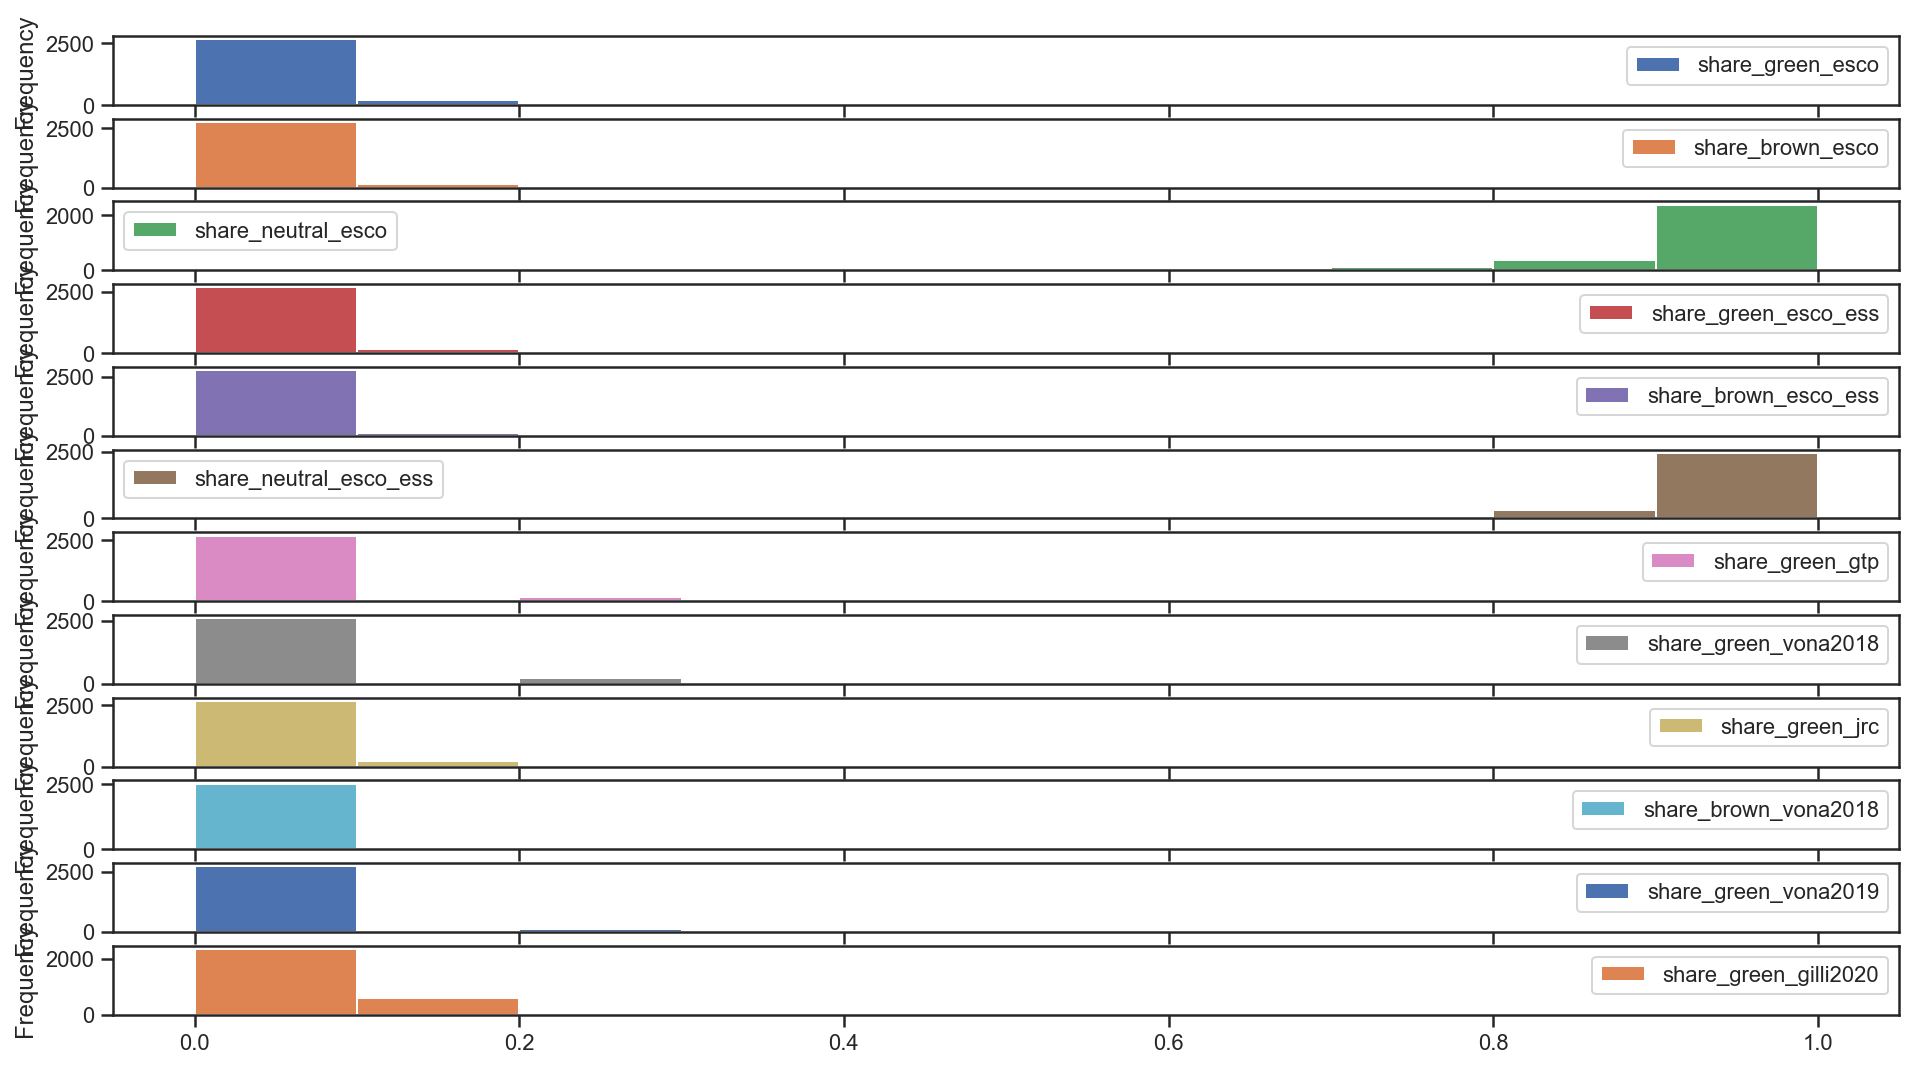

In [45]:
occ_master_ds.plot.hist(subplots=True)

Green split

In [ ]:
ds = occ_master_ds

In [ ]:
# concatenation
ds_meta = utils.extract_cols_by_kw(ds, "share", invert_selection=True)
ds_green = utils.extract_cols_by_kw(ds, "green")
ds_meta_green = pd.concat([ds_meta, ds_green], axis=1)

In [ ]:
# narrow selection (essential greenness > 0)
ds_meta_green_sel = ds_meta_green[
    (ds_meta_green.share_green_esco_ess > 0) &
    (
        (ds_meta_green.share_green_vona2018 > 0) |
        (ds_meta_green.share_green_gtp > 0) |
        (ds_meta_green.share_green_jrc > 0)
    )
]

utils.save_df_to_files(
    df=ds_meta_green_sel,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}_green_narrow".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

print(ds_meta_green_sel.shape[0])

In [ ]:
# wide selection (greenness > 0)
ds_meta_green_sel = ds_meta_green[
    (ds_meta_green.share_green_esco > 0) &
    (
        (ds_meta_green.share_green_vona2018 > 0) |
        (ds_meta_green.share_green_gtp > 0) |
        (ds_meta_green.share_green_jrc > 0)
    )
]

utils.save_df_to_files(
    df=ds_meta_green_sel,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}_green_wide".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

print(ds_meta_green_sel.shape[0])

Brown split

In [ ]:
ds_meta = utils.extract_cols_by_kw(ds, "share", invert_selection=True)
ds_brown = utils.extract_cols_by_kw(ds, "brown")
ds_meta_brown = pd.concat([ds_meta, ds_brown], axis=1)

In [ ]:
# narrow selection (essential brownness > 0)
ds_meta_brown_sel = ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco_ess > 0) &
    (ds_meta_brown.share_brown_vona2018 > 0)
]

utils.save_df_to_files(
    df=ds_meta_brown_sel,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}_brown_narrow".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

print(ds_meta_brown_sel.shape[0])

In [ ]:
# wide selection (brownness > 0)
ds_meta_brown_sel = ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco > 0) &
    (ds_meta_brown.share_brown_vona2018 > 0)
]

utils.save_df_to_files(
    df=ds_meta_brown_sel,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}_brown_wide".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

print(ds_meta_brown_sel.shape[0])

In [ ]:
# widest selection (boolean or)
ds_meta_brown_sel = ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco > 0) |
    (ds_meta_brown.share_brown_vona2018 > 0)
]

utils.save_df_to_files(
    df=ds_meta_brown_sel,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}_brown_widest".format(
        lvl="esco", nan_policy=out_folder_branch
    )
)

In [ ]:
ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco > 0) &
    (ds_meta_brown.share_brown_esco_ess == 0)
]

In [ ]:
esco.occupations

#### Unclear cases for brown occupations
1) brown_esco > 0 & brown_vona = 0: includes managers, professionals that are not caught by the industry-focus of the ONET data
2) brown_esco = 0 & brown_vona > 0

In [ ]:
ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco_ess > 0) &
    (ds_meta_brown.share_brown_vona2018 == 0)
]

In [ ]:
ds_meta_brown.loc[
    (ds_meta_brown.share_brown_esco_ess == 0) &
    (ds_meta_brown.share_brown_vona2018 > 0)
]

#### Impact/Influence of ESCO occupation hierarchy level

In [ ]:
occ_master_ds

In [ ]:
occ_hierarchy = pd.read_pickle(os.path.join(useful_paths.data_processed, "esco", "esco_occupation_hierarchy.pkl"))
occ_hierarchy_sub = utils.extract_cols_by_kw(occ_hierarchy, "esco")
occ_hierarchy_sub["conceptUri"] = occ_hierarchy["conceptUri"]
occ_hierarchy_sub.info()

In [ ]:
occ_master_ds_hierarchy = pd.merge(occ_master_ds, occ_hierarchy_sub, on="conceptUri", how="left")

In [ ]:
occ_master_ds_hierarchy.corr()

In [ ]:
occ_master_ds_hierarchy[occ_master_ds_hierarchy.is_esco_lvl_5].describe()

In [ ]:
occ_master_ds_hierarchy[occ_master_ds_hierarchy.is_esco_lvl_6].describe()

In [ ]:
occ_master_ds_hierarchy[occ_master_ds_hierarchy.is_esco_lvl_7].describe()

## Correlation analysis
How do the various greenness/brownness scores correlate at the level of ... ?
1) ESCO occupations
2) ISCO 4D occupations
3) ISCO 3D occupations

Notes
- comparison with nan's kept only makes sense at the ESCO level
- afterwards (ISCO 3-4 digits, imputation of nans necessary to correctly aggregate)

In [ ]:
from src.visualization.visualize import correlation_matrix_plot
import pingouin as pg
from pprint import pprint

#### Exploratory analysis

In [ ]:
np.unique(occ_master_ds.gbn_classification_esco, return_counts=True)

In [ ]:
np.unique(occ_master_ds.gbn_classification_esco_ess.dropna(), return_counts=True)

In [ ]:
occ_master_ds[occ_master_ds.gbn_classification_esco_ess == "green"]

In [ ]:
occ_master_ds[occ_master_ds.gbn_classification_esco == "brown"]

In [ ]:
pg.pairwise_corr(data=occ_master_ds, columns=["share_green_esco"])

In [ ]:
pg.pairwise_corr(data=occ_master_ds, columns=["share_brown_esco"])

In [ ]:
occ_master_ds.share_brown_vona2018.unique()

In [ ]:
# pg.logistic_regression(
#     X=occ_master_ds.share_brown_esco,
#     y=occ_master_ds.share_brown_vona2018,
#     remove_na=True
# )

In [ ]:
corr = pg.pairwise_corr(occ_master_ds)
corr.set_index(["X", "Y"])["r"].unstack()

#### Automated analysis

In [ ]:
# define and create output folder
out_folder = os.path.join(useful_paths.results_dir, "validation", "corr_occ_shares", out_folder_branch)
utils.ccdir(out_folder)

# define fpath formatter to files
fpath_out = os.path.join(
    out_folder, "{fname}.{dtype}"
)

fpath_out

In [ ]:
def corr_analysis_of_occ_shares(ds, lvl, fpath_out, figsize=(8,8), pval=0.001):
    # overview plot
    correlation_matrix_plot(ds, figsize=figsize, significance_level=pval)
    plt.savefig(fpath_out.format(fname="corr_{lvl}_level".format(lvl=lvl), dtype="png"),
                dpi=150)

    # Split by green and brown shares
    ds_green = utils.extract_cols_by_kw(ds, "green")
    ds_brown = utils.extract_cols_by_kw(ds, "brown")

    # green shares only
    pd.plotting.scatter_matrix(ds_green)
    plt.savefig(fpath_out.format(fname="scatter_matrix_{lvl}_level_green".format(lvl=lvl),
                                 dtype="png"),
                dpi=150)

    corr_table = pg.pairwise_corr(ds_green)
    corr_table.to_csv(fpath_out.format(fname="corr_esco_{lvl}_green".format(lvl=lvl),
                                       dtype="csv"))
    pprint(corr_table)

    # brown shares only
    pd.plotting.scatter_matrix(ds_brown)
    plt.savefig(fpath_out.format(fname="scatter_matrix_{lvl}_level_brown".format(lvl=lvl),
                                 dtype="png"),
                dpi=150)

    corr_table = pg.pairwise_corr(ds_brown)
    corr_table.to_csv(fpath_out.format(fname="corr_esco_{lvl}_brown".format(lvl=lvl),
                                       dtype="csv"))
    pprint(corr_table)

**ESCO level**

In [ ]:
# dataset selection (ESCO, ISCO4D, ISCO3D)
corr_analysis_of_occ_shares(ds=occ_master_ds, lvl="esco", fpath_out=fpath_out,
                            pval=pval)

**ISCO 4D level**

In [ ]:
occ_master_ds_isco4d = occ_master_ds.groupby("isco_level_4").mean()

utils.save_df_to_files(
    df=occ_master_ds_isco4d,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}".format(
        lvl="isco4d", nan_policy=out_folder_branch
    )
)

In [ ]:
occ_master_ds_isco4d

In [ ]:
# dataset selection (ESCO, ISCO4D, ISCO3D)
corr_analysis_of_occ_shares(ds=occ_master_ds_isco4d, lvl="isco4d",
                            fpath_out=fpath_out, pval=pval)

**ISCO 3D level**

In [ ]:
occ_master_ds_isco3d = occ_master_ds.groupby("isco_level_3").mean()

utils.save_df_to_files(
    df=occ_master_ds_isco3d,
    output_dir=os.path.join(useful_paths.data_interim, "esco"),
    fname_no_ext="occ_metadata_en_{lvl}_{nan_policy}".format(
        lvl="isco3d", nan_policy=out_folder_branch
    )
)

In [ ]:
# dataset selection (ESCO, ISCO4D, ISCO3D)
corr_analysis_of_occ_shares(ds=occ_master_ds_isco3d, lvl="isco3d",
                            fpath_out=fpath_out, pval=pval)